In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [4]:
data= pd.read_csv("heart_data_set.csv")

In [7]:
data.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,high_risk,age_band_risk,bmi_category,comorbidity_score,risk_score,risk_group
0,9046,1,67,0,1,Yes,Private,Urban,228.69,36.60,2,1,4,60+,obese,1,5,high_risk
1,51676,0,61,0,0,Yes,Self-employed,Rural,202.21,28.89,0,1,1,60+,Over_weight,0,2,low_risk
2,31112,1,80,0,1,Yes,Private,Rural,105.92,32.50,0,1,3,60+,obese,1,3,high_risk
3,60182,0,49,0,0,Yes,Private,Urban,171.23,34.40,3,1,2,45_60,obese,0,3,high_risk
4,1665,0,79,1,0,Yes,Self-employed,Rural,174.12,24.00,0,1,2,60+,Normal,1,3,high_risk
5,56669,1,81,0,0,Yes,Private,Urban,186.21,29.00,2,1,1,60+,Over_weight,0,3,high_risk
6,53882,1,74,1,1,Yes,Private,Rural,70.09,27.40,0,1,3,60+,Over_weight,2,3,high_risk
7,10434,0,69,0,0,No,Private,Urban,94.39,22.80,0,1,1,60+,Normal,0,1,low_risk
8,27419,0,59,0,0,Yes,Private,Rural,76.15,28.89,1,1,1,45_60,Over_weight,0,0,low_risk
9,60491,0,78,0,0,Yes,Private,Urban,58.57,24.20,1,1,1,60+,Normal,0,1,low_risk


In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   int64  
 2   age                5110 non-null   int64  
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                5110 non-null   float64
 10  smoking_status     5110 non-null   int64  
 11  stroke             5110 non-null   int64  
 12  high_risk          5110 non-null   int64  
 13  age_band_risk      5110 non-null   object 
 14  bmi_category       5110 non-null   object 
 15  comorbidity_score  5110 non-null   int64  
 16  risk_score         5110 

In [18]:
data.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
high_risk            0
age_band_risk        0
bmi_category         0
comorbidity_score    0
risk_score           0
risk_group           0
dtype: int64

In [11]:
data.isna().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [13]:
data.notnull().sum()

id                   5110
gender               5110
age                  5110
hypertension         5110
heart_disease        5110
ever_married         5110
work_type            5110
Residence_type       5110
avg_glucose_level    5110
bmi                  4909
smoking_status       5110
stroke               5110
dtype: int64

In [15]:
data.shape

(5110, 12)

In [17]:
data["bmi"].mean()

28.893236911794666

In [19]:
data["bmi"]=data["bmi"].fillna(data["bmi"].mean()).round(2)

In [21]:
data.isna().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [23]:
data.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.60,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.89,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.50,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.40,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.00,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.00,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.40,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.80,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,28.89,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.20,Unknown,1


In [25]:
data["smoking_status"].value_counts()

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64

In [27]:
data["age"].astype(int)

0       67
1       61
2       80
3       49
4       79
        ..
5105    80
5106    81
5107    35
5108    51
5109    44
Name: age, Length: 5110, dtype: int32

In [29]:
data["gender"].isna().sum()

0

In [31]:
data["smoking_status"]=data["smoking_status"].map({"never smoked":0,"Unknown":1,"formerly smoked":2,"smokes":3})

In [33]:
data.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.60,2,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.89,0,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.50,0,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.40,3,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.00,0,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.00,2,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.40,0,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.80,0,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,28.89,1,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.20,1,1


In [35]:
data["gender"].isna().sum()

0

In [37]:
data["age"].astype(int)

0       67
1       61
2       80
3       49
4       79
        ..
5105    80
5106    81
5107    35
5108    51
5109    44
Name: age, Length: 5110, dtype: int32

In [39]:
data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.60,2,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.89,0,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.50,0,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.40,3,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.00,0,1


In [41]:
data["age"].dtype

dtype('float64')

In [43]:
data["age"]=(data["age"].astype(int),inplace=True)

SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (4246086686.py, line 1)

In [45]:
data

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.60,2,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.89,0,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.50,0,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.40,3,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.00,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,28.89,0,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.00,0,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.60,0,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.60,2,0


In [47]:
data["age"]=data["age"].astype(int)

In [49]:
data["age"]

0       67
1       61
2       80
3       49
4       79
        ..
5105    80
5106    81
5107    35
5108    51
5109    44
Name: age, Length: 5110, dtype: int32

In [51]:
data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67,0,1,Yes,Private,Urban,228.69,36.60,2,1
1,51676,Female,61,0,0,Yes,Self-employed,Rural,202.21,28.89,0,1
2,31112,Male,80,0,1,Yes,Private,Rural,105.92,32.50,0,1
3,60182,Female,49,0,0,Yes,Private,Urban,171.23,34.40,3,1
4,1665,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.00,0,1


In [53]:
data["gender"].isna().sum()

0

In [55]:
data["gender"].value_counts()

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

In [57]:
data["gender"]=data["gender"].map({"Female":0,"Male":1,"Other":2})

In [59]:
data["gender"].head()

0    1
1    0
2    1
3    0
4    0
Name: gender, dtype: int64

In [61]:
data.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,1,67,0,1,Yes,Private,Urban,228.69,36.60,2,1
1,51676,0,61,0,0,Yes,Self-employed,Rural,202.21,28.89,0,1
2,31112,1,80,0,1,Yes,Private,Rural,105.92,32.50,0,1
3,60182,0,49,0,0,Yes,Private,Urban,171.23,34.40,3,1
4,1665,0,79,1,0,Yes,Self-employed,Rural,174.12,24.00,0,1
5,56669,1,81,0,0,Yes,Private,Urban,186.21,29.00,2,1
6,53882,1,74,1,1,Yes,Private,Rural,70.09,27.40,0,1
7,10434,0,69,0,0,No,Private,Urban,94.39,22.80,0,1
8,27419,0,59,0,0,Yes,Private,Rural,76.15,28.89,1,1
9,60491,0,78,0,0,Yes,Private,Urban,58.57,24.20,1,1


In [63]:
age_htn=data.groupby("hypertension")["age"].mean().round(2)
age_htn

hypertension
0    41.16
1    62.24
Name: age, dtype: float64

In [65]:
gen_bmi=pd.crosstab(data["gender"],data["bmi"]<=18.5)
gen_bmi

bmi,False,True
gender,,
0,2815,179
1,1945,170
2,1,0


In [67]:
gen_bmi_18_24=pd.crosstab(data["gender"],data["bmi"].between( 18.5,24.9))
gen_bmi_18_24

bmi,False,True
gender,,
0,2178,816
1,1689,426
2,0,1


In [69]:
gen_ow_25_29=pd.crosstab(data["gender"],data["bmi"].between( 25,29.5))
gen_ow_25_29

bmi,False,True
gender,,
0,2167,827
1,1434,681
2,1,0


In [71]:
gen_ob_30=pd.crosstab(data["gender"],data["bmi"]>=30)
gen_ob_30

bmi,False,True
gender,,
0,1879,1115
1,1310,805
2,1,0


In [73]:
stroke_vs_non_stroke_avg= data.groupby("stroke").agg(
    age=("age","mean"),
    bmi=("bmi","mean"),
    avg_glu=("avg_glucose_level","mean"),
    htn=("hypertension","mean"),
    heart_d=("heart_disease","mean")    
).round(2)

In [77]:
stroke_vs_non_stroke_avg

,age,bmi,avg_glu,htn,heart_d
stroke,,,,,
0,41.96,28.83,104.80,0.09,0.05
1,67.73,30.22,132.54,0.27,0.19


In [79]:
stroke_vs_non_stroke_median= data.groupby("stroke").agg(
    age=("age","median"),
    bmi=("bmi","median"),
    avg_glu=("avg_glucose_level","median"),
    htn=("hypertension","median"),
    heart_d=("heart_disease","median")    
).round(2)

In [81]:
stroke_vs_non_stroke_median

,age,bmi,avg_glu,htn,heart_d
stroke,,,,,
0,43.0,28.30,91.47,0.0,0.0
1,71.0,28.89,105.22,0.0,0.0


In [83]:
data["high_risk"]=(
    (data["age"]>=45).astype(int)+
    (data["bmi"]>=30)+
    (data["avg_glucose_level"]>=220)+
    (data["hypertension"]==1)+
    (data["heart_disease"]==1)
)

In [85]:
data["high_risk"].value_counts()

high_risk
0    1773
1    1725
2    1169
3     368
4      66
5       9
Name: count, dtype: int64

In [87]:
data["age_band_risk"]=pd.cut(
    data["age"],
    bins=[0,30,45,60,120],
    labels=["<30","30_45","45_60","60+"],
    right=False
)

In [89]:
data["age_band_risk"].value_counts()

age_band_risk
<30      1515
60+      1376
45_60    1201
30_45    1018
Name: count, dtype: int64

In [91]:
stroke_age_band=pd.crosstab(data["age_band_risk"],data["stroke"])
stroke_age_band

stroke,0,1
age_band_risk,,
<30,1513,2
30_45,1010,8
45_60,1143,58
60+,1195,181


In [93]:
stroke_rate=(
    stroke_age_band[1]/
    stroke_age_band.sum(axis=1)
)*100

In [95]:
stroke_rate=stroke_rate.round(2)
stroke_rate

age_band_risk
<30       0.13
30_45     0.79
45_60     4.83
60+      13.15
dtype: float64

In [97]:
final_results=pd.DataFrame({
    "Total_patients":stroke_age_band.sum(axis=1),
    "Stroke_patient":stroke_age_band[1],
    "stroke_rate":stroke_rate
})

In [99]:
final_results

,Total_patients,Stroke_patient,stroke_rate
age_band_risk,,,
<30,1515,2,0.13
30_45,1018,8,0.79
45_60,1201,58,4.83
60+,1376,181,13.15


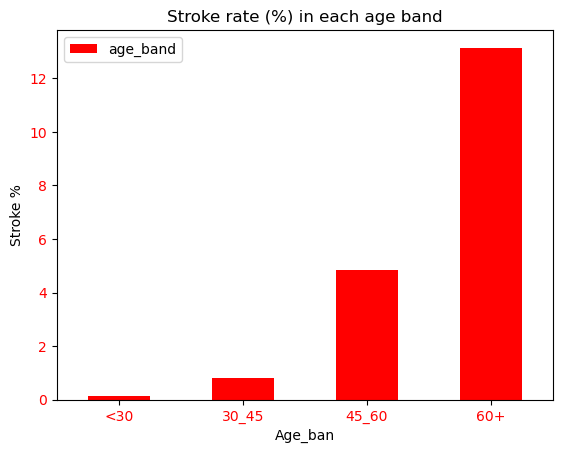

In [101]:
stroke_rate.plot(kind="bar", label="age_band",color="red")
plt.title("Stroke rate (%) in each age band")
plt.xlabel("Age_ban")
plt.ylabel("Stroke %")
plt.legend()
plt.xticks(rotation=0,color="red")
plt.yticks(rotation=0,color="red")
plt.show()

In [105]:
Bmi_bin=[0,18.5,24.9,29.9,100]
bmi_labels=["Under_weight","Normal","Over_weight","obese"]
data["bmi_category"]=pd.cut(
    data["bmi"],
    bins=Bmi_bin,
    labels=bmi_labels,
    right=False
)

In [107]:
stroke_bmi=pd.crosstab(data["bmi_category"],data["stroke"])
stroke_bmi

stroke,0,1
bmi_category,,
Under_weight,336,1
Normal,1181,35
Over_weight,1499,112
obese,1845,101


In [109]:
stroke_percent=(
    stroke_bmi[1]/
    stroke_bmi.sum(axis=1)
)*100

In [133]:
stroke_percent.round(2)

bmi_category
Under_weight    0.30
Normal          2.88
Over_weight     6.95
obese           5.19
dtype: float64

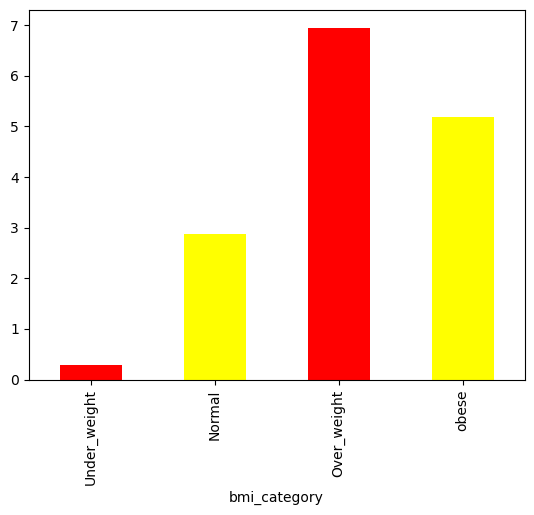

In [111]:
stroke_percent.plot(kind="bar",color=("red","yellow"))
plt.show()

In [113]:
final_percent_summary=pd.DataFrame({
    "total_patient":stroke_bmi.sum(axis=1),
    "stroke_patients":stroke_bmi[1],
    "stroke_rate":stroke_percent.round(2)
    
})

In [115]:
final_percent_summary

,total_patient,stroke_patients,stroke_rate
bmi_category,,,
Under_weight,337,1,0.30
Normal,1216,35,2.88
Over_weight,1611,112,6.95
obese,1946,101,5.19


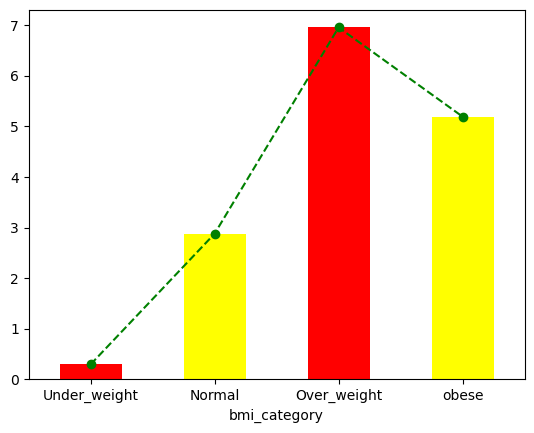

In [151]:
stroke_percent.plot(kind="bar",color=("red","yellow"))
stroke_percent.plot(kind="line",color="green",linestyle="--",marker="o")
plt.show()

In [117]:
stroke_smoke=pd.crosstab(data["smoking_status"],data["stroke"])

In [119]:
stroke_smoke

stroke,0,1
smoking_status,,
0,1802,90
1,1497,47
2,815,70
3,747,42


In [121]:
smoking_rate=(
    stroke_smoke[1]/
    stroke_smoke.sum(axis=1)
)*100

In [123]:
smoking_rate.round(2)

smoking_status
0    4.76
1    3.04
2    7.91
3    5.32
dtype: float64

In [125]:
final_marking=pd.DataFrame({
    "Total_patients":(stroke_smoke.sum(axis=1)),
    "stroke_patients":(stroke_smoke[1]),
    "Stroke_rate":(smoking_rate).round(2)

})

In [155]:
final_marking

,Total_patients,stroke_patients,Stroke_rate
smoking_status,,,
0,1892,90,4.76
1,1544,47,3.04
2,885,70,7.91
3,789,42,5.32


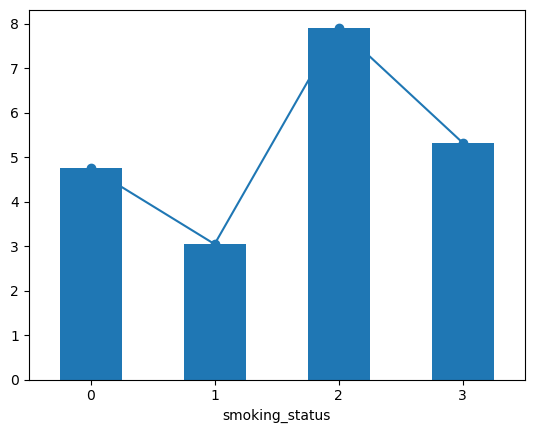

In [127]:
smoking_rate.plot(kind="bar")
smoking_rate.plot(kind="line",marker="o")
plt.show()

In [129]:
stroke_work=pd.crosstab(data["work_type"],data["stroke"])

In [131]:
stroke_work

stroke,0,1
work_type,,
Govt_job,624,33
Never_worked,22,0
Private,2776,149
Self-employed,754,65
children,685,2


In [133]:
stroke_work_rate=(
    stroke_work[1]/
    stroke_work.sum(axis=1)
)*100

In [135]:
stroke_work_rate.round(2)

work_type
Govt_job         5.02
Never_worked     0.00
Private          5.09
Self-employed    7.94
children         0.29
dtype: float64

In [157]:
final_summary=pd.DataFrame({
    "Total_patients":(stroke_work.sum(axis=1)),
    "Stroke_patients":(stroke_work[1]),
    "stroke_rate":(stroke_work_rate).round(2)
})

In [159]:
final_summary

,Total_patients,Stroke_patients,stroke_rate
work_type,,,
Govt_job,657,33,5.02
Never_worked,22,0,0.00
Private,2925,149,5.09
Self-employed,819,65,7.94
children,687,2,0.29


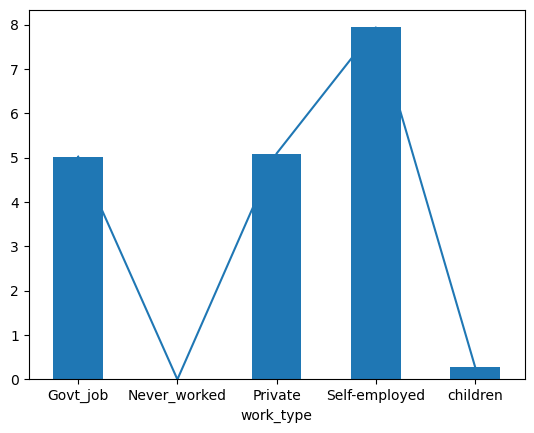

In [145]:
stroke_work_rate.plot(kind="bar")
stroke_work_rate.plot(kind="line")
plt.show()

In [161]:
stroke_residence=pd.crosstab(data["Residence_type"],data["stroke"])
stroke_residence

stroke,0,1
Residence_type,,
Rural,2400,114
Urban,2461,135


In [163]:
stroke_residence_rate=(
    stroke_residence[1]/
    stroke_residence.sum(axis=1)
)*100

In [165]:
stroke_residence_rate.round(2)

Residence_type
Rural    4.53
Urban    5.20
dtype: float64

In [167]:
final_table=pd.DataFrame({
    "Total_patients":(stroke_residence.sum(axis=1)),
    "stroke_patients":( stroke_residence[1]),
    "Stroke_rate":(stroke_residence_rate.round(2))
})

In [169]:
final_table

,Total_patients,stroke_patients,Stroke_rate
Residence_type,,,
Rural,2514,114,4.53
Urban,2596,135,5.20


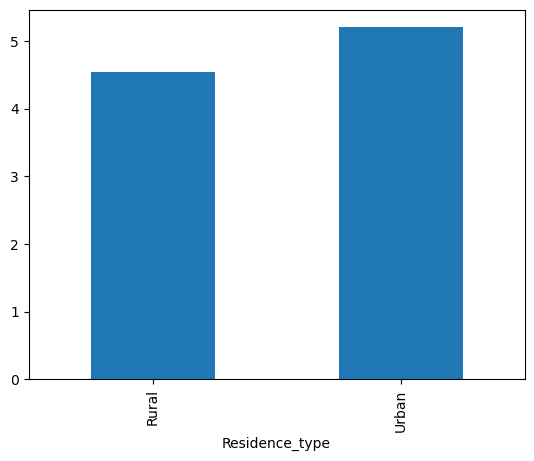

In [223]:
stroke_residence_rate.plot(kind="bar")
plt.show()

In [171]:
data["comorbidity_score"]=(
    (data["heart_disease"]==1).astype(int)+
    (data["hypertension"]==1).astype(int)
)

In [173]:
data["comorbidity_score"].value_counts()

comorbidity_score
0    4400
1     646
2      64
Name: count, dtype: int64

In [175]:
stroke_com=pd.crosstab(data["comorbidity_score"],data["stroke"])

In [177]:
stroke_com

stroke,0,1
comorbidity_score,,
0,4251,149
1,559,87
2,51,13


In [179]:
stroke_rate=(
    stroke_com[1]/
    stroke_com.sum(axis=1)
)*100

In [181]:
stroke_rate.round(2)

comorbidity_score
0     3.39
1    13.47
2    20.31
dtype: float64

In [183]:
data["risk_score"]=0
data.loc[data["age"]>=60,"risk_score"]+=1
data.loc[data["hypertension"]==1,"risk_score"]+=1
data.loc[data["heart_disease"]==1,"risk_score"]+=1
data.loc[data["bmi"]>=30,"risk_score"]+=1
data.loc[data["avg_glucose_level"]>=140,"risk_score"]+=1
data.loc[data["smoking_status"].isin([3,2]),"risk_score"]+=1
data[["age","risk_score"]].head(10)

,age,risk_score
0,67,5
1,61,2
2,80,3
3,49,3
4,79,3
5,81,3
6,74,3
7,69,1
8,59,0
9,78,1


In [185]:
data["risk_group"]=data["risk_score"].apply(
    lambda x:"high_risk" if x >=3 else "low_risk"
)

In [187]:
data["risk_group"].value_counts()

risk_group
low_risk     4324
high_risk     786
Name: count, dtype: int64

In [189]:
risk_counts=pd.crosstab(data["risk_group"],data["stroke"])
risk_counts

stroke,0,1
risk_group,,
high_risk,678,108
low_risk,4183,141


In [191]:
risk_rate=(
    risk_counts[1]/
    risk_counts.sum(axis=1)
)*100

In [193]:
risk_rate.round(2)

risk_group
high_risk    13.74
low_risk      3.26
dtype: float64

In [195]:
final_results=pd.DataFrame({
    "Total_patients":(risk_counts.sum(axis=1)),
    "stroke_patients":(risk_counts[1]),
    "risk_rate":(risk_rate.round(2))  
})

In [197]:
final_results

,Total_patients,stroke_patients,risk_rate
risk_group,,,
high_risk,786,108,13.74
low_risk,4324,141,3.26


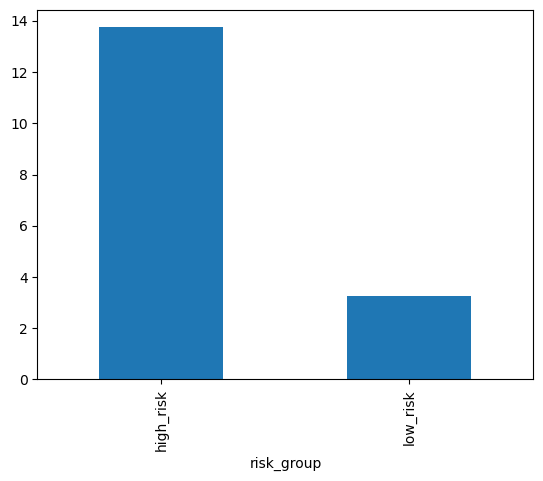

In [337]:
risk_rate.plot(kind="bar")
plt.show()

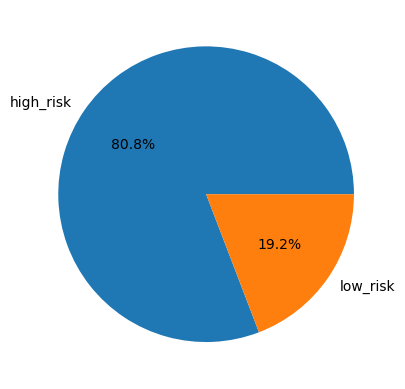

In [199]:
plt.pie(risk_rate,labels=risk_rate.index,autopct="%1.1f%%")
plt.show()

In [339]:
data.to_csv("stroke_data_set_raw.csv",index=False)

In [341]:
data=pd.read_csv("stroke_data_set_raw.csv")

In [343]:
data

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,high_risk,age_band_risk,bmi_category,comorbidity_score,risk_score,risk_group
0,9046,1,67,0,1,Yes,Private,Urban,228.69,36.60,2,1,4,60+,obese,1,5,high_risk
1,51676,0,61,0,0,Yes,Self-employed,Rural,202.21,28.89,0,1,1,60+,Over_weight,0,2,low_risk
2,31112,1,80,0,1,Yes,Private,Rural,105.92,32.50,0,1,3,60+,obese,1,3,high_risk
3,60182,0,49,0,0,Yes,Private,Urban,171.23,34.40,3,1,2,45_60,obese,0,3,high_risk
4,1665,0,79,1,0,Yes,Self-employed,Rural,174.12,24.00,0,1,2,60+,Normal,1,3,high_risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,0,80,1,0,Yes,Private,Urban,83.75,28.89,0,0,2,60+,Over_weight,1,2,low_risk
5106,44873,0,81,0,0,Yes,Self-employed,Urban,125.20,40.00,0,0,2,60+,obese,0,2,low_risk
5107,19723,0,35,0,0,Yes,Self-employed,Rural,82.99,30.60,0,0,1,30_45,obese,0,1,low_risk
5108,37544,1,51,0,0,Yes,Private,Rural,166.29,25.60,2,0,1,45_60,Over_weight,0,2,low_risk


In [349]:
from sklearn.model_selection import train_test_split

In [347]:
features=["gender","age","hypertension","avg_glucose_level","bmi","smoking_status","heart_disease"]
x=data[features]
y=data["stroke"]

In [351]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.20,random_state=100
)

In [353]:
x_train

,gender,age,hypertension,avg_glucose_level,bmi,smoking_status,heart_disease
1098,0,77,0,75.06,22.0,1,0
3465,0,28,0,141.16,36.7,0,0
3160,0,17,0,88.65,30.3,0,0
3594,0,62,0,226.38,47.4,0,0
1249,1,15,0,78.59,25.1,1,0
...,...,...,...,...,...,...,...
4149,0,81,1,59.11,20.7,2,1
1890,0,44,0,91.21,24.1,0,0
350,0,79,1,200.28,30.0,2,1
79,1,43,0,143.43,45.9,1,0


In [355]:
x_test

,gender,age,hypertension,avg_glucose_level,bmi,smoking_status,heart_disease
2918,0,63,0,239.95,32.2,3,1
3056,1,62,0,73.70,26.2,0,1
4916,1,54,0,72.96,37.7,3,0
4003,0,24,0,147.74,21.4,1,0
3332,1,27,0,114.32,28.1,1,0
...,...,...,...,...,...,...,...
3569,0,74,0,95.94,27.0,0,0
1876,0,47,0,140.39,25.5,0,0
757,1,19,0,84.31,31.8,0,0
3125,0,26,0,88.88,36.3,0,0


In [67]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [69]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(max_iter=2000,class_weight="balanced")
lr.fit(x_train_scaled,y_train)

LogisticRegression(class_weight='balanced', max_iter=2000)

In [33]:
y_prob=lr.predict_proba(x_test_scaled)[:,1]
y_predict=(y_prob>=0.3).astype(int)
y_train_pred=lr.predict(x_train_scaled)
y_test_pred=lr.predict(x_test_scaled)

In [35]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, r2_score,roc_curve

In [37]:
print(classification_report(y_test,y_test_pred))

              precision    recall  f1-score   support

           0       0.99      0.71      0.83       976
           1       0.12      0.85      0.21        46

    accuracy                           0.71      1022
   macro avg       0.56      0.78      0.52      1022
weighted avg       0.95      0.71      0.80      1022



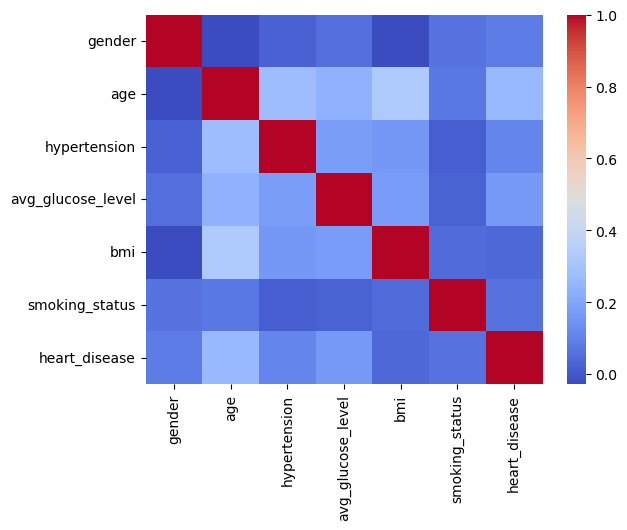

In [419]:
sns.heatmap(data[features].corr(),cmap="coolwarm")
plt.show()

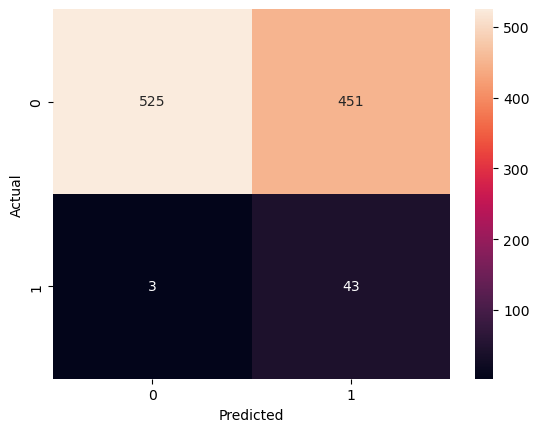

In [39]:
cm=confusion_matrix(y_test,y_predict)
sns.heatmap(cm,annot=True,fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

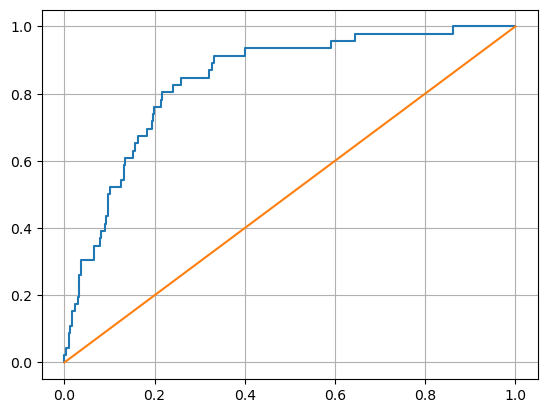

In [41]:
fpr,tpr,_=roc_curve(y_test,y_prob)
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],"-")
plt.grid()
plt.show()

In [43]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [45]:
y_lr_train_pred=lr.predict(x_train)
y_lr_test_pred=lr.predict(x_test)

In [47]:
y_lr_train_pred

array([ 0.11679768,  0.00472056, -0.02462059, ...,  0.22274385,
        0.03156432,  0.06744713])

In [431]:
y_lr_test_pred

array([ 0.15475923,  0.10961137,  0.053627  , ..., -0.01985187,
       -0.01359978, -0.02161257])

In [55]:
from sklearn.metrics import mean_squared_error, r2_score

In [53]:
lr_train_pred_mse=mean_squared_error(y_train,y_lr_train_pred)
lr_train_pred_r2=r2_score(y_train,y_lr_train_pred)
lr_test_pred_mse=mean_squared_error(y_test,y_lr_test_pred)
lr_test_pred_r2=r2_score(y_test,y_lr_test_pred)


In [57]:
lr_train_pred_mse

0.04375385651842436

In [59]:
lr_results=pd.DataFrame({"Model":["Linear Regression"],
                         "Train MSE":[lr_train_pred_mse],
                         "Train R2":[lr_train_pred_r2],
                         "Test MSE":[lr_test_pred_mse],
                         "Test R2":[lr_test_pred_r2]
})

In [61]:
lr_results

,Model,Train MSE,Train R2,Test MSE,Test R2
0,Linear Regression,0.043754,0.072848,0.039508,0.080863


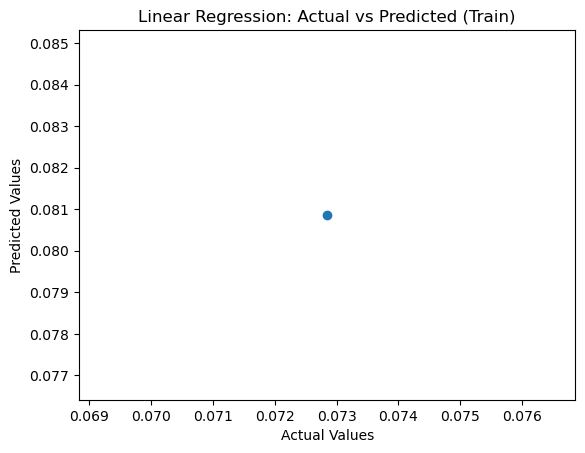

In [63]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(lr_train_pred_r2,lr_test_pred_r2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: Actual vs Predicted (Train)")
plt.show()


In [65]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   int64  
 2   age                5110 non-null   int64  
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                5110 non-null   float64
 10  smoking_status     5110 non-null   int64  
 11  stroke             5110 non-null   int64  
 12  high_risk          5110 non-null   int64  
 13  age_band_risk      5110 non-null   object 
 14  bmi_category       5110 non-null   object 
 15  comorbidity_score  5110 non-null   int64  
 16  risk_score         5110 

In [73]:
work_bmi=data.groupby("work_type")["bmi"].max()

In [75]:
work_bmi.round(2)

work_type
Govt_job         57.7
Never_worked     44.9
Private          97.6
Self-employed    64.8
children         41.7
Name: bmi, dtype: float64

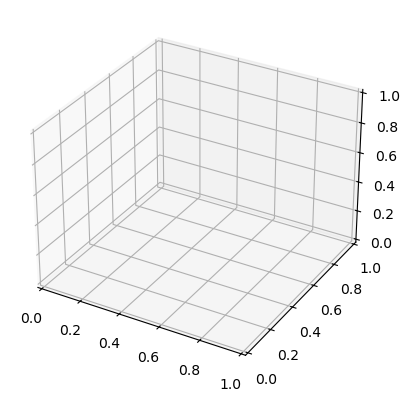

In [26]:
fig=plt.figure()
ax=plt.axes(projection="3d")
plt.show()

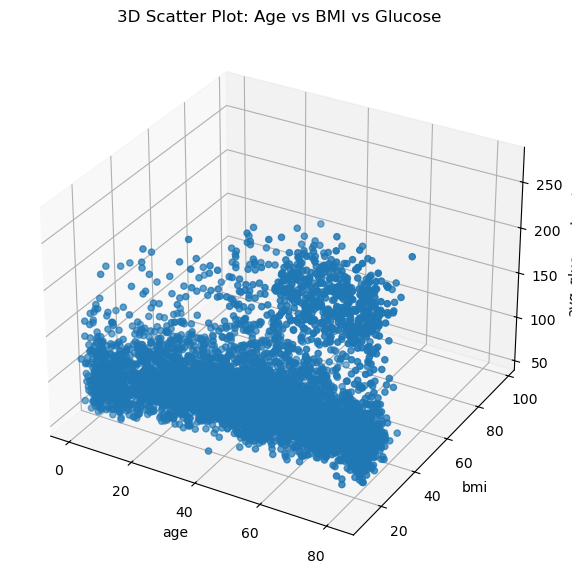

In [36]:
fig=plt.figure(figsize=(10,7))
ax=fig.add_subplot(111,projection="3d")
x=data["age"]
y=data["bmi"]
z=data["avg_glucose_level"]
ax.scatter(x,y,z)
ax.set_xlabel("age")
ax.set_ylabel("bmi")
ax.set_zlabel("avg_glucose_level")
ax.set_title("3D Scatter Plot: Age vs BMI vs Glucose")
plt.show()

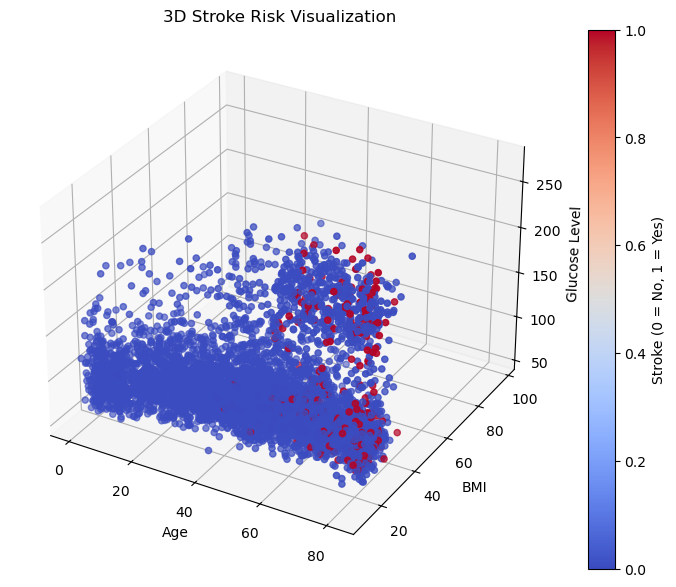

In [34]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    data['age'],
    data['bmi'],
    data['avg_glucose_level'],
    c=data['stroke'],
    cmap='coolwarm'
)

ax.set_xlabel("Age")
ax.set_ylabel("BMI")
ax.set_zlabel("Glucose Level")
ax.set_title("3D Stroke Risk Visualization")

plt.colorbar(sc, label="Stroke (0 = No, 1 = Yes)")
plt.show()


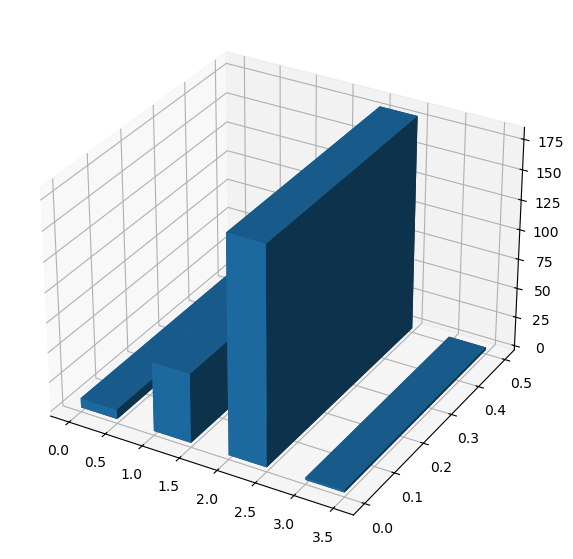

In [40]:
from mpl_toolkits.mplot3d import Axes3D
stroke_count=data.groupby("age_band_risk")["stroke"].sum()
x=np.arange(len(stroke_count))
y=np.zeros(len(stroke_count))
z=np.zeros(len(stroke_count))
dx=dy=0.5
dz=stroke_count.values
fig=plt.figure(figsize=(10,7))
ax=fig.add_subplot(111,projection="3d")
ax.bar3d(x,y,z,dx,dy,dz)
plt.show()

In [327]:
x=data[["age","bmi","avg_glucose_level","hypertension","heart_disease","gender"]]
y=data["stroke"]

In [329]:
from sklearn.model_selection import train_test_split
x_train,y_train,x_test,y_test=train_test_split(x,y,test_size=0.20,random_state=100)

In [359]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [301]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train_scaled,y_train)
lr.fit(x_test_scaled,y_test)

LinearRegression()

In [141]:
lr_train_pred=lr.predict(x_train_scaled)
lr_test_pred=lr.predict(x_test_scaled)

In [181]:
lr_train_pred

array([ 0.08262573,  0.01023559, -0.01802866, ...,  0.34025058,
        0.00970047,  0.0383196 ])

In [151]:
from sklearn.metrics import mean_squared_error, r2_score

In [191]:
mse_train=mean_squared_error(y_train,lr_train_pred)
mse_test=mean_squared_error(y_test,lr_test_pred)
r2_train=r2_score(y_train,lr_train_pred)
r2_test=r2_score(y_test,lr_test_pred)

In [155]:
mse_train

0.044798875388165495

In [183]:
mse_test

0.03834076699755199

In [187]:
r2_train

0.050703619485171214

In [193]:
r2_test

0.10802036536281434

In [225]:
lr_results=pd.DataFrame({"Model":["Linear regression"],"Mse train ":[mse_train],"mse test":[mse_test],"r2 score":[r2_train],"r2_test":[r2_test]})
    
lr_results

,Model,Mse train,mse test,r2 score,r2_test
0,Linear regression,0.052104,0.0,-0.104087,1.0


In [275]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(n_estimators=200,max_depth=10)
rf.fit(x_train_scaled,y_train)
rf.fit(x_test_scaled,y_test)

RandomForestRegressor(max_depth=10, n_estimators=200)

In [279]:
rf_train_pred=rf.predict(x_train_scaled)
rf_test_pred=rf.predict(x_test_scaled)

In [281]:
mse_train=mean_squared_error(y_train,rf_train_pred)
mse_test=mean_squared_error(y_test,rf_test_pred)
r2_train=r2_score(y_train,rf_train_pred)
r2_test=r2_score(y_test,rf_test_pred)

In [285]:
rf_results=pd.DataFrame({"Model":["Random Forest Classifier"],"Mse train ":[mse_train],"mse test":[mse_test],"r2 score":[r2_train],"r2_test":[r2_test]})
rf_results

,Model,Mse train,mse test,r2 score,r2_test
0,Random Forest Classifier,0.046445,0.006437,0.015828,0.850242


In [291]:
final_results=pd.concat([lr_results,rf_results],ignore_index=True)
final_results

,Model,Mse train,mse test,r2 score,r2_test
0,Linear regression,0.052104,0.000000,-0.104087,1.000000
1,Random Forest Classifier,0.046445,0.006437,0.015828,0.850242


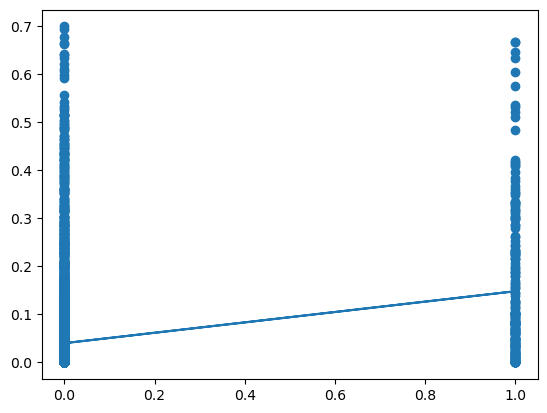

In [289]:
plt.scatter(x=y_train,y=rf_train_pred)
z=np.polyfit(y_train,rf_train_pred,1)
p=np.poly1d(z)
plt.plot(y_train,p(y_train))
plt.show()

In [307]:
y = data['avg_glucose_level']
X = data[
    ['age',
     'bmi',
     'hypertension',
     'heart_disease',
     'stroke']
]


In [309]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [311]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [313]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

lr_mse = mean_squared_error(y_test, lr_pred)
lr_r2  = r2_score(y_test, lr_pred)

print("Linear Regression")
print("MSE:", lr_mse)
print("R2 :", lr_r2)


Linear Regression
MSE: 1785.1935086157132
R2 : 0.0715883493122752


In [315]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2  = r2_score(y_test, rf_pred)

print("\nRandom Forest Regressor")
print("MSE:", rf_mse)
print("R2 :", rf_r2)



Random Forest Regressor
MSE: 1869.0651126327264
R2 : 0.027969899012373123


In [317]:
if rf_r2 > lr_r2:
    print("Random Forest is better")
else:
    print("Linear Regression is better")


Linear Regression is better


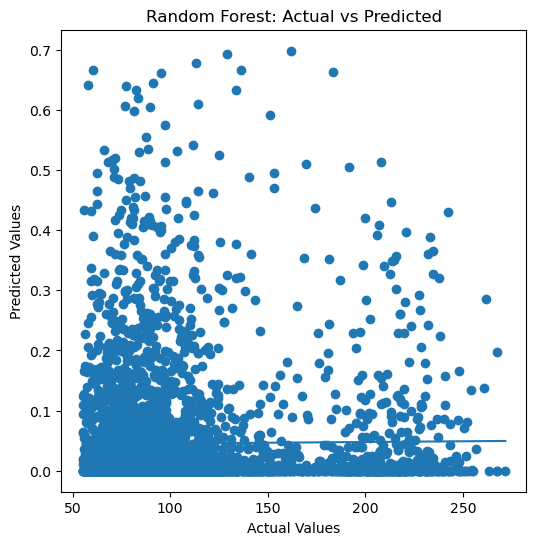

In [319]:
import numpy as np
import matplotlib.pyplot as plt

# convert to numpy
y_true = y_train.values
y_pred = rf_train_pred

# scatter plot
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred)

# best fit line
z = np.polyfit(y_true, y_pred, 1)
p = np.poly1d(z)

# sort for straight line
idx = np.argsort(y_true)

plt.plot(y_true[idx], p(y_true[idx]))

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest: Actual vs Predicted")

plt.show()


In [357]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(max_depth=5,random_state=42)
dt.fit(x,y)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [361]:
y_pred=dt.predict(x_test)

In [365]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9579256360078278

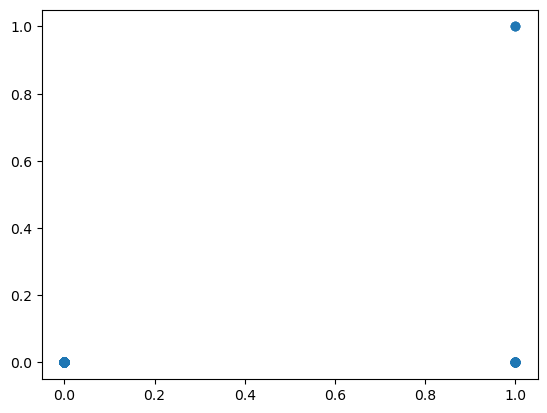

In [369]:
plt.scatter(y_test,y_pred)
plt.show()

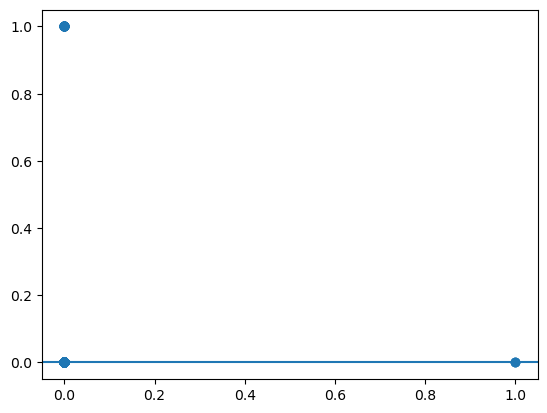

In [381]:
residuals=y_test - y_pred
plt.scatter(y_pred,residuals)
plt.axhline(0)
plt.show()